# Analysis of Temporal Trends in Peat Burn Proportion

This notebook analyzes whether there has been a significant increase in the proportion of burned area that occurs on peat soils in Alaska. We'll use the outputs from our fire analysis script to:

1. Load and process the annual burned area data
2. Analyze temporal trends using statistical tests
3. Visualize the changes over time with confidence intervals

First, let's import the required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import pymannkendall as mk

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("deep")

## 1. Load and Prepare Data

Load the data from the analysis script's output CSV, which contains:
- Total burned area per year
- Burned area on peat per year
- Proportion of burned area on peat

In [2]:
# Load the data
df = pd.read_csv("outputs/fire_area_on_peat_by_year.csv")

# Set year as index
df = df.set_index("FIREYEAR")

# Basic statistics
print("Data period:", df.index.min(), "to", df.index.max())
print("\nSummary statistics:")
print(df.describe())

Data period: 1940 to 2024

Summary statistics:
       total_area_ha  peat_area_ha  peat_proportion
count   8.000000e+01      80.00000        80.000000
mean    3.780151e+05   66143.99250         0.181647
std     5.559145e+05  100096.26548         0.082848
min     5.184201e+02      96.16000         0.018186
25%     4.635451e+04    9764.04000         0.117742
50%     1.492052e+05   34853.52000         0.179335
75%     3.890689e+05   61365.98000         0.233879
max     2.685199e+06  511267.72000         0.406384


## 2. Statistical Trend Analysis

We'll use several approaches to test for temporal trends in the peat burn proportion:

1. Mann-Kendall test: A non-parametric test for monotonic trends
2. Sen's slope: A robust estimator of trend magnitude
3. Simple linear regression for comparison

These tests will help us determine if there's a significant trend in the proportion of burned area occurring on peat.

In [3]:
# 1. Mann-Kendall test (guarded)

mk_result = mk.original_test(df['peat_proportion'])
print("Mann-Kendall test results:")
print(f"Trend: {'increasing' if getattr(mk_result, 'trend', None) == 'increasing' or getattr(mk_result, 'h', False) else 'no clear increasing trend'}")
# mk_result may have different attribute names depending on version
p_val = getattr(mk_result, 'p', None)
tau = getattr(mk_result, 'Tau', None) or getattr(mk_result, 'tau', None)
print(f"p-value: {p_val:.4f}" if p_val is not None else "p-value: N/A")
print(f"Tau: {tau:.4f}" if tau is not None else "Tau: N/A")

# 2. Sen's slope (use Theil-Sen via SciPy for robustness)
from scipy.stats import theilslopes
# Use absolute year values for Theil-Sen
x_years = df.index.astype(int).to_numpy()
y = df['peat_proportion'].to_numpy()
if len(x_years) >= 2:
    try:
        theil_res = theilslopes(y, x_years, 0.95)
        sens_slope = theil_res[0]
        sens_intercept = theil_res[1]
        sens_lower = theil_res[2]
        sens_upper = theil_res[3]
        print("\nTheil-Sen (Sen's slope) estimate:")
        print(f"Slope: {sens_slope:.6f} (proportion per year)")
    except Exception as e:
        sens_slope = np.nan
        print("Could not compute Theil-Sen slope:", e)
else:
    sens_slope = np.nan
    print("Not enough data to compute Theil-Sen slope")

# 3. Linear regression (for comparison)
# Create a relative years array for regression (0,1,2,...)
years = (x_years - x_years.min()).astype(float)
slope, intercept, r_value, p_value, std_err = stats.linregress(years, y)
print("\nLinear regression results:")
print(f"Slope: {slope:.6f} (proportion/year)")
print(f"R-squared: {r_value**2:.4f}")
print(f"p-value: {p_value:.4f}")

# Store results for plotting
# fitted values on the same scale as df.index (use relative years)
df['trend_year'] = years
# intercept here is the intercept from linear regression relative to years starting at 0
# to get fitted on the original index, we can compute using relative years
df['fitted'] = intercept + slope * years


Mann-Kendall test results:
Trend: increasing
p-value: 0.0003
Tau: 0.2747

Theil-Sen (Sen's slope) estimate:
Slope: 0.001494 (proportion per year)

Linear regression results:
Slope: 0.001369 (proportion/year)
R-squared: 0.1589
p-value: 0.0002


## 3. Visualization with Confidence Intervals

Let's create a comprehensive visualization that shows:
1. The actual proportion of burned area on peat over time
2. The fitted trend line
3. 95% confidence intervals for the trend
4. A 5-year moving average to show medium-term patterns

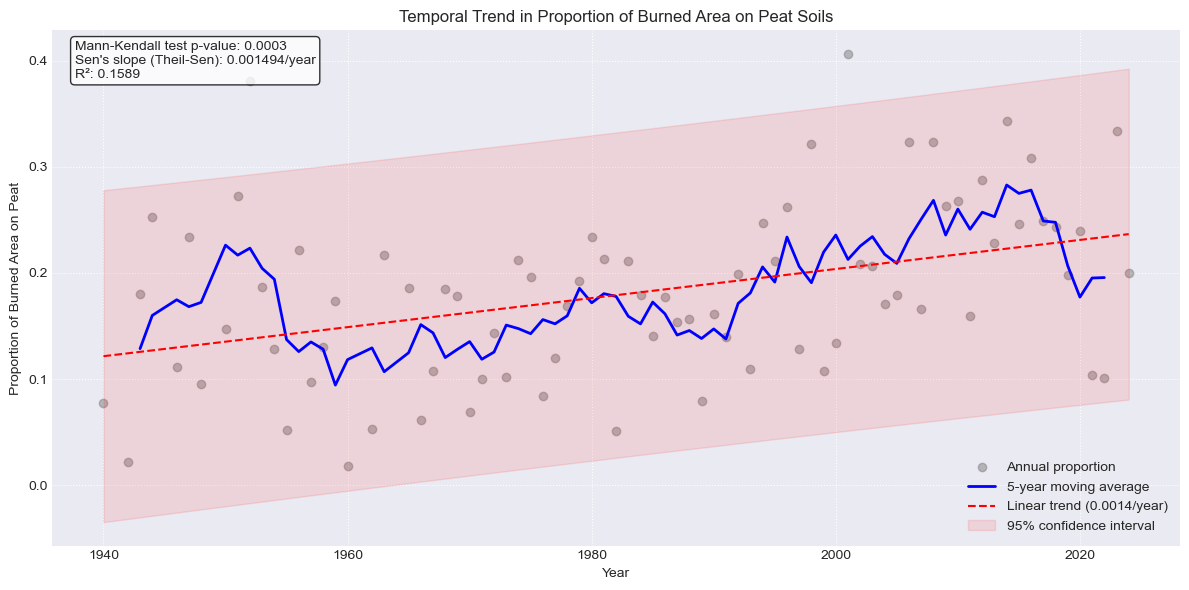

Saved trend analysis plot to outputs/peat_burn_proportion_trend_analysis.png


In [ ]:
# Create the visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actual data points
ax.scatter(df.index, df['peat_proportion'], 
          alpha=0.5, label='Annual proportion', color='gray')

# Plot 5-year moving average
rolling_mean = df['peat_proportion'].rolling(window=5, center=True).mean()
ax.plot(df.index, rolling_mean, color='blue', 
        label='5-year moving average', linewidth=2)

# Plot trend line with confidence intervals
conf = 0.95
# Use the relative years array defined earlier for variance calculations
degrees_freedom = len(years) - 2
if degrees_freedom > 0:
    t_value = stats.t.ppf((1 + conf) / 2, degrees_freedom)
    sigma_est = np.sqrt(np.sum((df['peat_proportion'] - df['fitted'])**2) / degrees_freedom)
else:
    t_value = np.nan
    sigma_est = np.nan

x_new = np.linspace(years.min(), years.max(), 100)
y_new = intercept + slope * x_new
# Prediction interval (approx)
if not np.isnan(t_value):
    pi = t_value * sigma_est * np.sqrt(1 + 1/len(years) + 
        (x_new - np.mean(years))**2 / np.sum((years - np.mean(years))**2))
else:
    pi = np.zeros_like(x_new) + np.nan

# Convert x_new back to actual years for plotting
actual_years = x_new + df.index.min()

ax.plot(actual_years, y_new, 'r--', label=f'Linear trend ({slope:.4f}/year)')
ax.fill_between(actual_years, y_new - pi, y_new + pi, 
                color='red', alpha=0.1, label='95% confidence interval')

# Customize plot
ax.set_xlabel('Year')
ax.set_ylabel('Proportion of Burned Area on Peat')
ax.set_title('Temporal Trend in Proportion of Burned Area on Peat Soils')
ax.grid(True, linestyle=':')
ax.legend()

# Add annotation with statistical results
mk_p = mk_result.p if (mk_result is not None and hasattr(mk_result, 'p')) else np.nan
r2 = r_value**2 if 'r_value' in locals() else np.nan
sens_val = sens_slope if 'sens_slope' in locals() else np.nan
stats_text = f"Mann-Kendall test p-value: {mk_p:.4f}\n"
stats_text += f"Sen's slope (Theil-Sen): {sens_val:.6f}/year\n"
stats_text += f"R²: {r2:.4f}"
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Also save the plot
fig.savefig("outputs/exploratory/fire_perimeters/peat_burn_proportion_trend_analysis.png", dpi=300, bbox_inches='tight')
print("Saved trend analysis plot to outputs/exploratory/fire_perimeters/peat_burn_proportion_trend_analysis.png")

## 4. Results Interpretation

The analysis provides several key insights:

1. **Trend Detection**: The Mann-Kendall test determines if there's a significant monotonic trend (increasing or decreasing) without assuming linearity.

2. **Trend Magnitude**: Sen's slope provides a robust estimate of the rate of change, while linear regression gives us a standard measure of trend strength (R²).

3. **Visualization**: The plot shows:
   - Raw annual proportions (gray points)
   - 5-year moving average (blue line) to show medium-term patterns
   - Linear trend (red dashed line)
   - 95% confidence interval (red shaded area)
   
4. **Statistical Significance**: The p-values from both Mann-Kendall and linear regression tests tell us whether the observed trend is statistically significant (p < 0.05 indicates significance).

## 5. Breakpoint (Change-point) Analysis

We'll test whether there is a statistically-detectable change point in the time series of peat burn proportion. We'll use:

- Pettitt's test (non-parametric, single change-point test implemented here)
- ruptures library (if installed) for a model-based change-point detection (can detect one or multiple breaks)

If rupture detection finds a breakpoint, we'll report the year, p-value (from Pettitt) and the mean proportion before and after the break, and show vertical line(s) on the time series plot.

Pettitt test: change point at index 48 -> year 1993; p-value ~ 0.0004402
Mean before: 0.1503; Mean after: 0.2312
Ruptures detected breakpoint around index 49 -> year 1994


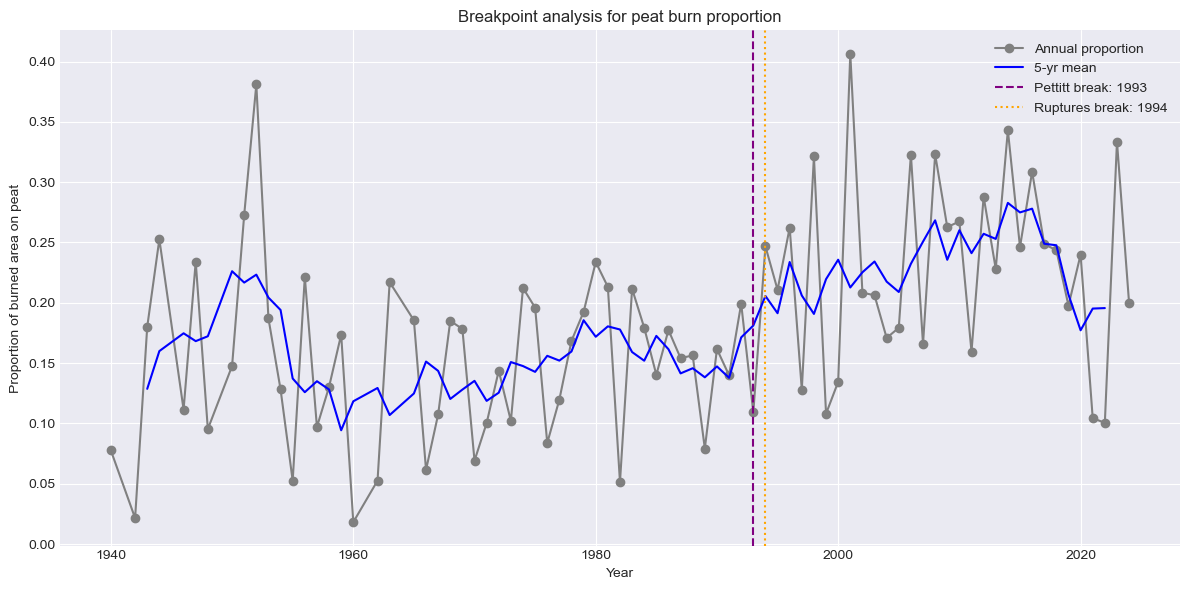

Saved breakpoint plot to outputs/peat_burn_proportion_breakpoints.png


In [ ]:
# Breakpoint analysis: Pettitt's test implementation and optional ruptures-based detection

def pettitt_test(x):
    """Return index of change point, Kmax, and approximate p-value using Pettitt's test.
    x: 1-D array-like
    """
    x = np.asarray(x)
    n = len(x)
    if n < 2:
        return None, None, None
    K = np.zeros(n, dtype=float)
    # compute U statistic for each t
    for t in range(n):
        s = 0
        for i in range(t + 1):
            # compare x[i] with x[j] for j>t
            s += np.sum(np.sign(x[i] - x[t + 1:]))
        K[t] = s
    Kt = np.abs(K)
    Kmax = Kt.max()
    t_star = int(Kt.argmax())
    # approximate p-value (two-sided)
    p = 2 * np.exp((-6 * (Kmax ** 2)) / (n ** 3 + n ** 2))
    return t_star, Kmax, p


series = df['peat_proportion'].dropna()
if len(series) < 3:
    print("Not enough data for breakpoint analysis")
else:
    idx, Kmax, pval = pettitt_test(series.values)
    if idx is not None:
        break_year = series.index[idx]
        print(f"Pettitt test: change point at index {idx} -> year {break_year}; p-value ~ {pval:.4g}")
        mean_before = series.values[: idx + 1].mean()
        mean_after = series.values[idx + 1 :].mean()
        print(f"Mean before: {mean_before:.4f}; Mean after: {mean_after:.4f}")
    else:
        print("Pettitt test did not return a breakpoint")

    # Try using ruptures if available for model-based detection (detect 1 breakpoint)
    try:
        import ruptures as rpt
        algo = rpt.Binseg(model="l2").fit(series.values)
        bkps = algo.predict(n_bkps=1)  # returns list of break indices (including len)
        # bkps is list with the last element equal to len(series); first breakpoint is bkps[0]
        if len(bkps) > 0:
            bidx = bkps[0] - 1
            rupt_break_year = series.index[bidx]
            print(f"Ruptures detected breakpoint around index {bidx} -> year {rupt_break_year}")
        else:
            rupt_break_year = None
    except Exception as e:
        rupt_break_year = None
        print("ruptures not available or error running it; skipping model-based detection:", e)

    # Plot with breakpoint(s)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(series.index, series.values, marker='o', linestyle='-', color='gray', label='Annual proportion')
    ax.plot(series.index, series.rolling(window=5, center=True).mean(), color='blue', label='5-yr mean')
    if idx is not None:
        ax.axvline(break_year, color='purple', linestyle='--', label=f'Pettitt break: {break_year}')
    if rupt_break_year is not None and rupt_break_year != break_year:
        ax.axvline(rupt_break_year, color='orange', linestyle=':', label=f'Ruptures break: {rupt_break_year}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Proportion of burned area on peat')
    ax.set_title('Breakpoint analysis for peat burn proportion')
    ax.legend()
    plt.tight_layout()
    plt.show()
    fig.savefig("outputs/exploratory/fire_perimeters/peat_burn_proportion_breakpoints.png", dpi=200, bbox_inches='tight')
    print("Saved breakpoint plot to outputs/exploratory/fire_perimeters/peat_burn_proportion_breakpoints.png")


In [6]:
# Compute mean peat proportion for contiguous periods defined by breakpoints and save summary
import os

# Breakpoints (years where periods change)
breaks = [1961, 1968, 1986, 2015]
# Define contiguous, non-overlapping periods based on breaks:
#  - up to the year before the first break (<= 1960)
#  - 1961-1968: many missing fire reports
#  - 1969-1986: emphasis on mapping perimeters of at least 1,000 acres
#  - 1987-2015: emphasis on mapping wildfires with perimeters of at least 100 acres
#  - 2016 and later: fires over 10 acres should be associated with perimeters
periods = [
    (None, breaks[0] - 1, f"up_to_{breaks[0]-1}"),
    (breaks[0], breaks[1], f"{breaks[0]}_{breaks[1]}"),
    (breaks[1] + 1, breaks[2], f"{breaks[1]+1}_{breaks[2]}"),
    (breaks[2] + 1, breaks[3], f"{breaks[2]+1}_{breaks[3]}"),
    (breaks[3] + 1, None, f"since_{breaks[3]+1}"),
]

series = df['peat_proportion'].dropna()
if series.empty:
    print("No peat proportion data available to compute means.")
else:
    years = series.index.astype(int)

    def summarize_range(start, end, label):
        if start is None:
            mask = years <= end
        elif end is None:
            mask = years >= start
        else:
            mask = (years >= start) & (years <= end)
        s = series.loc[mask]
        if s.empty:
            return {"period": label, "start": start, "end": end, "n": 0, "mean_peat_proportion": np.nan}
        return {"period": label, "start": int(s.index.min()), "end": int(s.index.max()), "n": int(len(s)), "mean_peat_proportion": float(s.mean())}

    rows = [summarize_range(start, end, label) for (start, end, label) in periods]

    out_df = pd.DataFrame(rows)
    os.makedirs('outputs', exist_ok=True)
    out_path = 'outputs/peat_proportion_means_periods.csv'
    out_df.to_csv(out_path, index=False)

    # Print results
    for r in rows:
        print(f"{r['period']}: start={r['start']}, end={r['end']}, n={r['n']}, mean_peat_proportion={r['mean_peat_proportion']:.4f}")

    print(f"Wrote period summary to {out_path}")

up_to_1960: start=1940, end=1960, n=18, mean_peat_proportion=0.1546
1961_1968: start=1962, end=1968, n=6, mean_peat_proportion=0.1349
1969_1986: start=1969, end=1986, n=18, mean_peat_proportion=0.1541
1987_2015: start=1987, end=2015, n=29, mean_peat_proportion=0.2134
since_2016: start=2016, end=2024, n=9, mean_peat_proportion=0.2196
Wrote period summary to outputs/peat_proportion_means_periods.csv


In [36]:
# Calculate average annual total burned area (2016-2023)
area_2016_2023 = df.loc[(df.index >= 2016) & (df.index <= 2024), 'total_area_ha']
avg_total_area = area_2016_2023.mean()

print(f"Average annual total burned area (2016-2023): {avg_total_area:,.0f} ha/year")


Average annual total burned area (2016-2023): 401,114 ha/year


In [2]:
# Calculate average peat area from Lara Peat dataset (2002-2023)
import pandas as pd
print("\n" + "=" * 70)
print("LARA PEAT AVERAGE BURNED AREA (2002-2023)")
print("=" * 70)

lara_peat_path = "data/peat/LaraPeat_MCD64A1_Alaska_Annual_Burned_Area_2001_2024.csv"
lara_peat_df = pd.read_csv(lara_peat_path)

# Filter for 2002-2023
lara_2002_2023 = lara_peat_df.loc[(lara_peat_df['year'] >= 2002) & (lara_peat_df['year'] <= 2023), 'burned_area_ha']

if len(lara_2002_2023) > 0:
    avg_lara_peat = lara_2002_2023.mean()
    min_lara_peat = lara_2002_2023.min()
    max_lara_peat = lara_2002_2023.max()
    n_years = len(lara_2002_2023)
    
    print(f"\nAverage peat area burned (2002-2023):")
    print(f"  Years included: {n_years}")
    print(f"  Average: {avg_lara_peat:,.0f} ha/year")
    print(f"  Minimum: {min_lara_peat:,.0f} ha (year {lara_2002_2023.idxmin()})")
    print(f"  Maximum: {max_lara_peat:,.0f} ha (year {lara_2002_2023.idxmax()})")
    print(f"  Standard deviation: {lara_2002_2023.std():,.0f} ha")
else:
    print("No data found for 2002-2023")

print("=" * 70)


LARA PEAT AVERAGE BURNED AREA (2002-2023)

Average peat area burned (2002-2023):
  Years included: 22
  Average: 187,792 ha/year
  Minimum: 4,129 ha (year 10)
  Maximum: 851,231 ha (year 3)
  Standard deviation: 239,086 ha


In [ ]:
# Calculate average peat area from Lara Peat dataset (2002-2023)
import pandas as pd
print("\n" + "=" * 70)
print("ALASKA TOTAL AVERAGE ANNUAL BURNED AREA (2002-2023)")
print("=" * 70)

ak_ba_path = "data/peat/Total_MCD64A1_Alaska_Annual_Burned_Area_2001_2024.csv"
ak_ba_df = pd.read_csv(ak_ba_path)

# Filter for 2002-2023
ak_ba_2002_2023 = ak_ba_df.loc[(ak_ba_df['year'] >= 2002) & (ak_ba_df['year'] <= 2023), 'burned_area_ha']

if len(ak_ba_2002_2023) > 0:
    avg_ak_ba = ak_ba_2002_2023.mean()
    min_ak_ba = ak_ba_2002_2023.min()
    max_ak_ba = ak_ba_2002_2023.max()
    n_years = len(ak_ba_2002_2023)
    
    print(f"\nAverage peat area burned (2002-2023):")
    print(f"  Years included: {n_years}")
    print(f"  Average: {avg_ak_ba:,.0f} ha/year")
    print(f"  Minimum: {min_ak_ba:,.0f} ha (year {ak_ba_2002_2023.idxmin()})")
    print(f"  Maximum: {max_ak_ba:,.0f} ha (year {ak_ba_2002_2023.idxmax()})")
    print(f"  Standard deviation: {ak_ba_2002_2023.std():,.0f} ha")
else:
    print("No data found for 2002-2023")

print("=" * 70)


ALASKA TOTAL AVERAGE ANNUAL BURNED AREA (2002-2023)

Average peat area burned (2002-2023):
  Years included: 22
  Average: 415,728 ha/year
  Minimum: 18,247 ha (year 10)
  Maximum: 2,077,856 ha (year 3)
  Standard deviation: 550,871 ha


: 

In [5]:
# Calculate greenhouse gas emissions in tCO2e for mean peat area burned in a specified period

# ===== USER-CONFIGURABLE PARAMETERS =====
start_year = 2002
end_year = 2023
# ========================================

# Mean peat area burned in the specified period
# period_data = df.loc[(df.index >= start_year) & (df.index <= end_year), 'peat_area_ha']
# mean_peat_area = period_data.mean()
mean_peat_area = avg_lara_peat

print("=" * 70)
print(f"PARAMETERS:")
print("=" * 70)

# Input parameters
dry_matter_per_ha = 66  # tonnes DM/ha
co2_per_kg_dm = (362 * 44 / 12)  # grams → calculated from molar ratios
co_per_kg_dm = 209  # grams
ch4_per_kg_dm = 9  # grams

# Global Warming Potentials (100-year)
gwp_co2 = 1
gwp_co = 1.9
gwp_ch4 = 27

print(f"\nInput Data:")
print(f"  Mean peat area burned ({start_year}-{end_year}): {mean_peat_area:,.0f} ha/year")
print(f"  IPCC Dry matter burned per hectare: {dry_matter_per_ha} tonnes DM/ha")
print(f"\nIPCC Emission Factors (per kg of Dry Matter):")
print(f"  CO2: {co2_per_kg_dm:.2f} grams = {co2_per_kg_dm/1000:.4f} kg")
print(f"  CO: {co_per_kg_dm} grams = {co_per_kg_dm/1000:.3f} kg")
print(f"  CH4: {ch4_per_kg_dm} grams = {ch4_per_kg_dm/1000:.3f} kg")
print(f"\nIPCC Global Warming Potentials (100-year horizont):")
print(f"  CO2: {gwp_co2}")
print(f"  CO: {gwp_co}")
print(f"  CH4: {gwp_ch4}")

# Calculations
print(f"\n" + "=" * 70)
print("CALCULATION:")
print("=" * 70)

# Step 1: Total dry matter burned
total_dm_tonnes = mean_peat_area * dry_matter_per_ha
total_dm_kg = total_dm_tonnes * 1000
print(f"\n1. Total dry matter burned:")
print(f"   {mean_peat_area:,.0f} ha × {dry_matter_per_ha} tonnes/ha")
print(f"   = {total_dm_kg:,.0f} kg DM")

# Step 2: Emissions by gas (in kg)
co2_emissions_kg = total_dm_kg * (co2_per_kg_dm / 1000)
co_emissions_kg = total_dm_kg * (co_per_kg_dm / 1000)
ch4_emissions_kg = total_dm_kg * (ch4_per_kg_dm / 1000)

print(f"\n2. Total emissions by gas:")
print(f"   CO2: {total_dm_kg:,.0f} kg × {co2_per_kg_dm/1000:.4f} kg/kg = {co2_emissions_kg:,.0f} kg")
print(f"   CO:  {total_dm_kg:,.0f} kg × {co_per_kg_dm/1000:.3f} kg/kg = {co_emissions_kg:,.0f} kg")
print(f"   CH4: {total_dm_kg:,.0f} kg × {ch4_per_kg_dm/1000:.3f} kg/kg = {ch4_emissions_kg:,.0f} kg")

# Step 3: Convert to CO2e (tonnes)
co2_co2e = co2_emissions_kg * gwp_co2 / 1000  # convert kg to tonnes
co_co2e = co_emissions_kg * gwp_co / 1000
ch4_co2e = ch4_emissions_kg * gwp_ch4 / 1000

print(f"\n3. Convert to CO2e (using GWPs):")
print(f"   CO2: {co2_emissions_kg:,.0f} kg × {gwp_co2} = {co2_co2e:,.0f} tCO2e")
print(f"   CO:  {co_emissions_kg:,.0f} kg × {gwp_co} = {co_co2e:,.0f} tCO2e")
print(f"   CH4: {ch4_emissions_kg:,.0f} kg × {gwp_ch4} = {ch4_co2e:,.0f} tCO2e")

# Step 4: Total CO2e
total_co2e = co2_co2e + co_co2e + ch4_co2e

print(f"\n" + "=" * 70)
print(f"TOTAL EMISSIONS ({start_year}-{end_year} annual average):")
print(f"=" * 70)
print(f"  Total CO2e: {total_co2e:,.0f} tCO2e/year")
print(f"\nBreakdown by gas:")
print(f"  CO2:  {co2_co2e:,.0f} tCO2e ({100*co2_co2e/total_co2e:.1f}%)")
print(f"  CO:   {co_co2e:,.0f} tCO2e ({100*co_co2e/total_co2e:.1f}%)")
print(f"  CH4:  {ch4_co2e:,.0f} tCO2e ({100*ch4_co2e/total_co2e:.1f}%)")
print("=" * 70)


PARAMETERS:

Input Data:
  Mean peat area burned (2002-2023): 187,792 ha/year
  IPCC Dry matter burned per hectare: 66 tonnes DM/ha

IPCC Emission Factors (per kg of Dry Matter):
  CO2: 1327.33 grams = 1.3273 kg
  CO: 209 grams = 0.209 kg
  CH4: 9 grams = 0.009 kg

IPCC Global Warming Potentials (100-year horizont):
  CO2: 1
  CO: 1.9
  CH4: 27

CALCULATION:

1. Total dry matter burned:
   187,792 ha × 66 tonnes/ha
   = 12,394,295,457 kg DM

2. Total emissions by gas:
   CO2: 12,394,295,457 kg × 1.3273 kg/kg = 16,451,361,503 kg
   CO:  12,394,295,457 kg × 0.209 kg/kg = 2,590,407,750 kg
   CH4: 12,394,295,457 kg × 0.009 kg/kg = 111,548,659 kg

3. Convert to CO2e (using GWPs):
   CO2: 16,451,361,503 kg × 1 = 16,451,362 tCO2e
   CO:  2,590,407,750 kg × 1.9 = 4,921,775 tCO2e
   CH4: 111,548,659 kg × 27 = 3,011,814 tCO2e

TOTAL EMISSIONS (2002-2023 annual average):
  Total CO2e: 24,384,950 tCO2e/year

Breakdown by gas:
  CO2:  16,451,362 tCO2e (67.5%)
  CO:   4,921,775 tCO2e (20.2%)
  CH4: 

In [4]:
# FAO Data Analysis: Calculate CO2e from component emissions
print("\n" + "=" * 80)
print("FAO AVERAGE EMISSIONS (2016-2023)")
print("  CH4 + CO2 + CO as CO2e")
print("=" * 80)

fao_path = "data/fire/MCD64.006.yearly-fao-emissions-burned-area-faostat.2016-2023.USA_United States.USA.2_1_Alaska.csv"
fao_df = pd.read_csv(fao_path)


# Calculate CO2e from component emissions
# CH4 - Methane as CO2 equiv. [t] - already in CO2e
# CO - Carbon Monoxide [t] - need to convert to CO2e using GWP of 1.9
# CO2 - Carbon Dioxide [t] - already in CO2e form

gwp_co_fao = 1.9

# Sum the CO2 equivalents from the three main gases
fao_df['CH4_CO2e'] = fao_df['CH4 - Methane as CO2 equiv. [t]']
fao_df['CO_CO2e'] = fao_df['CO - Carbon Monoxide [t]'] * gwp_co_fao
fao_df['CO2_CO2e'] = fao_df['CO2 - Carbon Dioxide [t]']
fao_df['Calculated_Total_CO2e'] = fao_df['CH4_CO2e'] + fao_df['CO_CO2e'] + fao_df['CO2_CO2e']

# Calculate averages
fao_ch4_avg = fao_df['CH4_CO2e'].mean()
fao_co_avg = fao_df['CO_CO2e'].mean()
fao_co2_avg = fao_df['CO2_CO2e'].mean()
fao_calc_total_avg = fao_df['Calculated_Total_CO2e'].mean()

print(f"\nComponent averages (CO2 equivalent):")
print(f"  CH4 (as CO2e):              {fao_ch4_avg:,.0f} tCO2e/year")
print(f"  CO (converted at GWP=1.9):  {fao_co_avg:,.0f} tCO2e/year")
print(f"  CO2 (direct):               {fao_co2_avg:,.0f} tCO2e/year")
print(f"  ────────────────────────────")
print(f"  Total from components:      {fao_calc_total_avg:,.0f} tCO2e/year")
print(f"\nBreakdown by gas:")
print(f"  CH4:  {100*fao_ch4_avg/fao_calc_total_avg:.1f}%")
print(f"  CO:   {100*fao_co_avg/fao_calc_total_avg:.1f}%")
print(f"  CO2:  {100*fao_co2_avg/fao_calc_total_avg:.1f}%")
print("=" * 80)


FAO AVERAGE EMISSIONS (2016-2023)
  CH4 + CO2 + CO as CO2e

Component averages (CO2 equivalent):
  CH4 (as CO2e):              243,666 tCO2e/year
  CO (converted at GWP=1.9):  400,296 tCO2e/year
  CO2 (direct):               3,745,371 tCO2e/year
  ────────────────────────────
  Total from components:      4,389,334 tCO2e/year

Breakdown by gas:
  CH4:  5.6%
  CO:   9.1%
  CO2:  85.3%


In [5]:
# GFED Data Analysis: Calculate emissions from component emissions
print("\n" + "=" * 80)
print("GFED AVERAGE EMISSIONS (2016-2023)")
print("  CH4 + CO2 + CO as CO2e")
print("=" * 80)

gfed_path = "data/fire/MCD64.006.yearly-gfed-emissions-burned-area.2016-2023.USA_United States.USA.2_1_Alaska.csv"
gfed_df = pd.read_csv(gfed_path)

gwp_co_fao = 1.9
gwp_ch4_fao = 27

# Sum the three main gases: CH4, CO2, and CO
# No GWP conversion needed - these are direct mass emissions in tonnes
gfed_df['CH4_tonnes'] = gfed_df['CH4 - Methane [t]'] * gwp_ch4_fao
gfed_df['CO2_tonnes'] = gfed_df['CO2 - Carbon Dioxide [t]']
gfed_df['CO_tonnes'] = gfed_df['CO - Carbon Monoxide [t]'] * gwp_co_fao
gfed_df['Calculated_Total_Tonnes'] = gfed_df['CH4_tonnes'] + gfed_df['CO2_tonnes'] + gfed_df['CO_tonnes']

gfed_comparison = gfed_df[['Year', 'CH4_tonnes', 'CO2_tonnes', 'CO_tonnes', 'Calculated_Total_Tonnes', 'Total Emissions [t]']].copy()
gfed_comparison['Difference'] = gfed_comparison['Calculated_Total_Tonnes'] - gfed_comparison['Total Emissions [t]']
gfed_comparison['Percent_of_Total'] = (gfed_comparison['Calculated_Total_Tonnes'] / gfed_comparison['Total Emissions [t]'] * 100)

# Calculate averages
gfed_ch4_avg = gfed_df['CH4_tonnes'].mean()
gfed_co2_avg = gfed_df['CO2_tonnes'].mean()
gfed_co_avg = gfed_df['CO_tonnes'].mean()
gfed_calc_total_avg = gfed_df['Calculated_Total_Tonnes'].mean()

print(f"\nComponent averages (tonnes):")
print(f"  CH4 (Methane):              {gfed_ch4_avg:,.0f} tCO2e/year")
print(f"  CO2 (Carbon Dioxide):       {gfed_co2_avg:,.0f} tCO2e/year")
print(f"  CO (Carbon Monoxide):       {gfed_co_avg:,.0f} tCO2e/year")
print(f"  ────────────────────────────")
print(f"  Total from components:      {gfed_calc_total_avg:,.0f} tCO2e/year")

print(f"\nBreakdown by gas (% of CH4+CO2+CO):")
print(f"  CH4:  {100*gfed_ch4_avg/gfed_calc_total_avg:.1f}%")
print(f"  CO:   {100*gfed_co_avg/gfed_calc_total_avg:.1f}%")
print(f"  CO2:  {100*gfed_co2_avg/gfed_calc_total_avg:.1f}%")
print("=" * 80)


GFED AVERAGE EMISSIONS (2016-2023)
  CH4 + CO2 + CO as CO2e

Component averages (tonnes):
  CH4 (Methane):              3,758,630 tCO2e/year
  CO2 (Carbon Dioxide):       32,400,312 tCO2e/year
  CO (Carbon Monoxide):       5,301,087 tCO2e/year
  ────────────────────────────
  Total from components:      41,460,030 tCO2e/year

Breakdown by gas (% of CH4+CO2+CO):
  CH4:  9.1%
  CO:   12.8%
  CO2:  78.1%



COMPARATIVE EMISSIONS ANALYSIS (2016-2023)

Annual Emissions Comparison (tCO2e):
 Year  Peat_Emissions_tCO2e  FAO_Emissions_tCO2e  GFED_Emissions_tCO2e
 2016          7.885128e+06         1.391663e+06          8.976513e+06
 2017          9.407255e+06         2.066609e+06          2.877241e+07
 2018          5.686652e+06         1.192335e+06          1.038003e+07
 2019          2.701482e+07         1.650283e+07          1.117294e+08
 2020          2.328446e+06         3.863227e+05          1.681458e+06
 2021          1.409453e+06         8.424272e+05          9.678362e+06
 2022          1.681380e+07         1.109389e+07          1.466471e+08
 2023          5.995826e+06         1.638602e+06          1.381492e+07

Saved comparative emissions plot to outputs/emissions_comparison_2016-2023.png


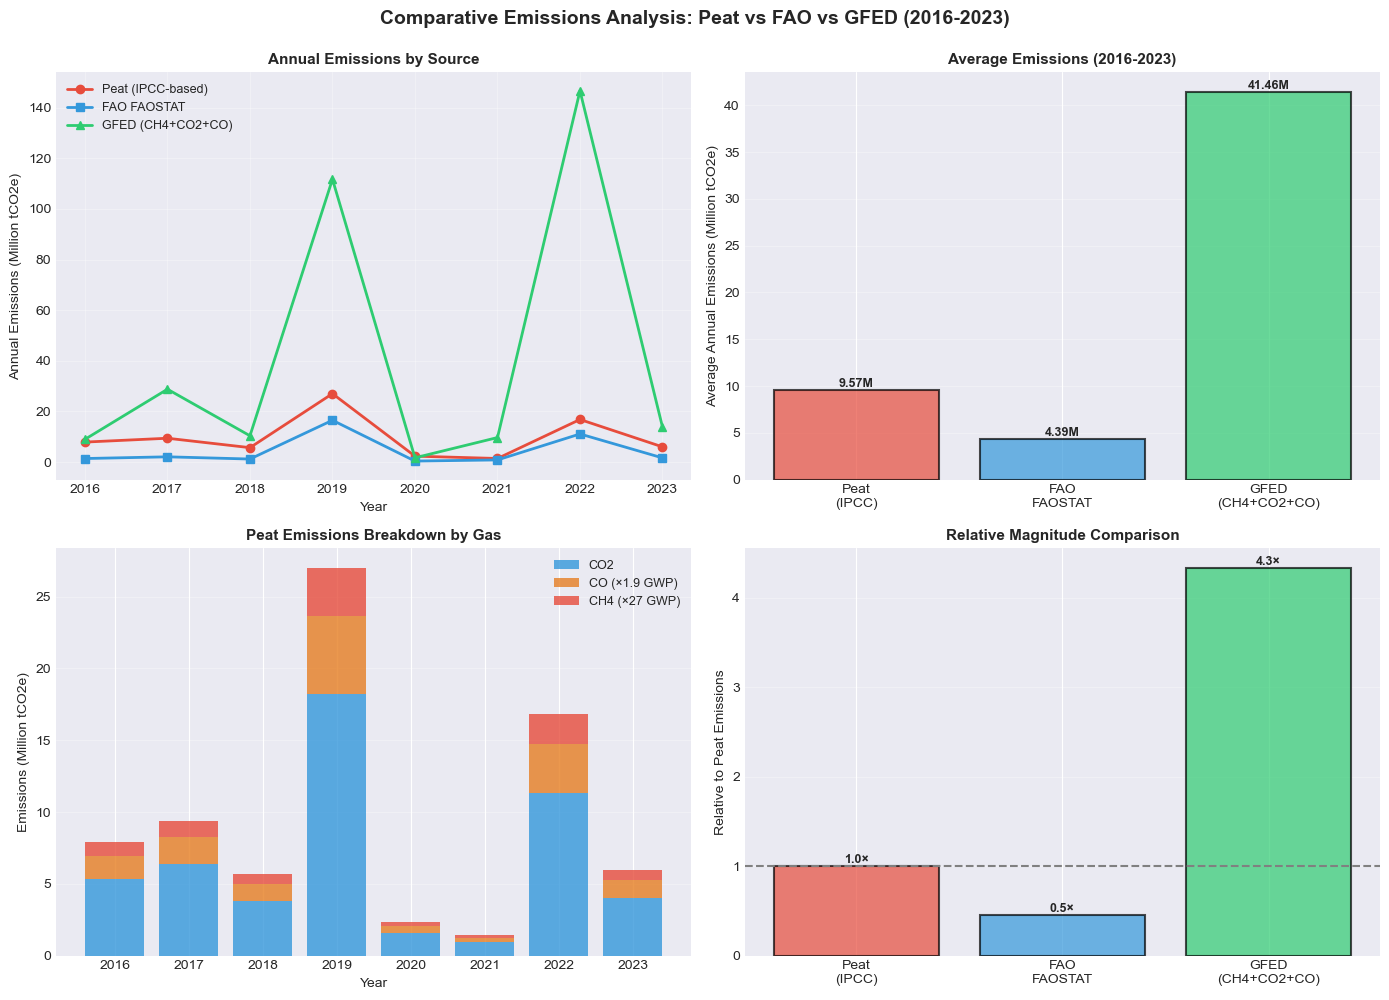


SUMMARY STATISTICS (2016-2023)

Peat Emissions (IPCC-based calculation):
  Average: 9,567,671 tCO2e/year
  Range: 1,409,453 - 27,014,816 tCO2e

FAO Emissions (component sum: CH4+CO+CO2):
  Average: 4,389,334 tCO2e/year
  Range: 386,323 - 16,502,825 tCO2e

GFED Emissions (component sum: CH4+CO+CO2 with GWPs):
  Average: 41,460,030 tCO2e/year
  Range: 1,681,458 - 146,647,113 tCO2e

Relative Magnitudes (ratio to Peat):
  FAO / Peat:  0.46×
  GFED / Peat: 4.33×


In [6]:
# Comparative Emissions Visualization (2016-2023)
print("\n" + "=" * 80)
print("COMPARATIVE EMISSIONS ANALYSIS (2016-2023)")
print("=" * 80)

# Calculate annual peat emissions for 2016-2023
peat_annual = []
years_list = []
for year in range(2016, 2024):
    if year in df.index:
        peat_area = df.loc[year, 'peat_area_ha']
        
        # Same calculation as Cell 13 but per year
        total_dm_tonnes = peat_area * 66
        total_dm_kg = total_dm_tonnes * 1000
        
        co2_emissions_kg = total_dm_kg * (1327.33 / 1000)
        co_emissions_kg = total_dm_kg * (209 / 1000)
        ch4_emissions_kg = total_dm_kg * (9 / 1000)
        
        co2_co2e = co2_emissions_kg * 1 / 1000
        co_co2e = co_emissions_kg * 1.9 / 1000
        ch4_co2e = ch4_emissions_kg * 27 / 1000
        
        total_co2e_year = co2_co2e + co_co2e + ch4_co2e
        peat_annual.append(total_co2e_year)
        years_list.append(year)

peat_df = pd.DataFrame({
    'Year': years_list,
    'Peat_Emissions_tCO2e': peat_annual
})

# Extract annual data from FAO
fao_annual = fao_df[['Year', 'Calculated_Total_CO2e']].copy()
fao_annual.columns = ['Year', 'FAO_Emissions_tCO2e']

# Extract annual data from GFED
gfed_annual = gfed_df[['Year', 'Calculated_Total_Tonnes']].copy()
gfed_annual.columns = ['Year', 'GFED_Emissions_tCO2e']

# Merge all three datasets
emissions_comparison = peat_df.merge(fao_annual, on='Year').merge(gfed_annual, on='Year')

print("\nAnnual Emissions Comparison (tCO2e):")
print(emissions_comparison.to_string(index=False))

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparative Emissions Analysis: Peat vs FAO vs GFED (2016-2023)', 
             fontsize=14, fontweight='bold', y=0.995)

# 1. Annual emissions time series (all three)
ax1 = axes[0, 0]
ax1.plot(emissions_comparison['Year'], emissions_comparison['Peat_Emissions_tCO2e']/1e6, 
         marker='o', linewidth=2, label='Peat (IPCC-based)', color='#e74c3c')
ax1.plot(emissions_comparison['Year'], emissions_comparison['FAO_Emissions_tCO2e']/1e6, 
         marker='s', linewidth=2, label='FAO FAOSTAT', color='#3498db')
ax1.plot(emissions_comparison['Year'], emissions_comparison['GFED_Emissions_tCO2e']/1e6, 
         marker='^', linewidth=2, label='GFED (CH4+CO2+CO)', color='#2ecc71')
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Annual Emissions (Million tCO2e)', fontsize=10)
ax1.set_title('Annual Emissions by Source', fontsize=11, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(2016, 2024))

# 2. Average emissions bar chart
ax2 = axes[0, 1]
sources = ['Peat\n(IPCC)', 'FAO\nFAOSTAT', 'GFED\n(CH4+CO2+CO)']
averages = [
    emissions_comparison['Peat_Emissions_tCO2e'].mean() / 1e6,
    emissions_comparison['FAO_Emissions_tCO2e'].mean() / 1e6,
    emissions_comparison['GFED_Emissions_tCO2e'].mean() / 1e6
]
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax2.bar(sources, averages, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Average Annual Emissions (Million tCO2e)', fontsize=10)
ax2.set_title('Average Emissions (2016-2023)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, val in zip(bars, averages):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Peat emissions breakdown (annual)
ax3 = axes[1, 0]
peat_co2_annual = []
peat_co_annual = []
peat_ch4_annual = []
for year in years_list:
    peat_area = df.loc[year, 'peat_area_ha']
    total_dm_tonnes = peat_area * 66
    total_dm_kg = total_dm_tonnes * 1000
    
    co2_emissions_kg = total_dm_kg * (1327.33 / 1000)
    co_emissions_kg = total_dm_kg * (209 / 1000)
    ch4_emissions_kg = total_dm_kg * (9 / 1000)
    
    peat_co2_annual.append(co2_emissions_kg * 1 / 1000 / 1e6)
    peat_co_annual.append(co_emissions_kg * 1.9 / 1000 / 1e6)
    peat_ch4_annual.append(ch4_emissions_kg * 27 / 1000 / 1e6)

ax3.bar(years_list, peat_co2_annual, label='CO2', color='#3498db', alpha=0.8)
ax3.bar(years_list, peat_co_annual, bottom=peat_co2_annual, label='CO (×1.9 GWP)', color='#e67e22', alpha=0.8)
bottom_co2_co = [peat_co2_annual[i] + peat_co_annual[i] for i in range(len(years_list))]
ax3.bar(years_list, peat_ch4_annual, bottom=bottom_co2_co, label='CH4 (×27 GWP)', color='#e74c3c', alpha=0.8)
ax3.set_xlabel('Year', fontsize=10)
ax3.set_ylabel('Emissions (Million tCO2e)', fontsize=10)
ax3.set_title('Peat Emissions Breakdown by Gas', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticks(range(2016, 2024))

# 4. Relative comparison (normalized to peat average)
ax4 = axes[1, 1]
peat_avg = emissions_comparison['Peat_Emissions_tCO2e'].mean()
fao_avg = emissions_comparison['FAO_Emissions_tCO2e'].mean()
gfed_avg = emissions_comparison['GFED_Emissions_tCO2e'].mean()

relative = [peat_avg, fao_avg, gfed_avg]
relative_normalized = [x/peat_avg for x in relative]

bars2 = ax4.bar(sources, relative_normalized, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, label='Peat baseline (1.0×)')
ax4.set_ylabel('Relative to Peat Emissions', fontsize=10)
ax4.set_title('Relative Magnitude Comparison', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
# Add multiplier labels
for bar, val in zip(bars2, relative_normalized):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/emissions_comparison_2016-2023.png', dpi=300, bbox_inches='tight')
print("\nSaved comparative emissions plot to outputs/emissions_comparison_2016-2023.png")
plt.show()

# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS (2016-2023)")
print("=" * 80)
print(f"\nPeat Emissions (IPCC-based calculation):")
print(f"  Average: {emissions_comparison['Peat_Emissions_tCO2e'].mean():,.0f} tCO2e/year")
print(f"  Range: {emissions_comparison['Peat_Emissions_tCO2e'].min():,.0f} - {emissions_comparison['Peat_Emissions_tCO2e'].max():,.0f} tCO2e")
print(f"\nFAO Emissions (component sum: CH4+CO+CO2):")
print(f"  Average: {emissions_comparison['FAO_Emissions_tCO2e'].mean():,.0f} tCO2e/year")
print(f"  Range: {emissions_comparison['FAO_Emissions_tCO2e'].min():,.0f} - {emissions_comparison['FAO_Emissions_tCO2e'].max():,.0f} tCO2e")
print(f"\nGFED Emissions (component sum: CH4+CO+CO2 with GWPs):")
print(f"  Average: {emissions_comparison['GFED_Emissions_tCO2e'].mean():,.0f} tCO2e/year")
print(f"  Range: {emissions_comparison['GFED_Emissions_tCO2e'].min():,.0f} - {emissions_comparison['GFED_Emissions_tCO2e'].max():,.0f} tCO2e")
print(f"\nRelative Magnitudes (ratio to Peat):")
print(f"  FAO / Peat:  {emissions_comparison['FAO_Emissions_tCO2e'].mean() / emissions_comparison['Peat_Emissions_tCO2e'].mean():.2f}×")
print(f"  GFED / Peat: {emissions_comparison['GFED_Emissions_tCO2e'].mean() / emissions_comparison['Peat_Emissions_tCO2e'].mean():.2f}×")
print("=" * 80)
